In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt
from tqdm import tqdm  # for progress bar
import re


In [2]:
# Initialize list to store book data
books_data = []

# Base URL for all 50 pages
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

In [3]:
# Loop through all pages (1 to 50)
for page in tqdm(range(1, 51)):
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all book containers
    books = soup.find_all('article', class_='product_pod')

    for book in books:
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text.strip()
        availability = book.find('p', class_='instock availability').text.strip()
        rating_class = book.p['class'][1]

        # Store as dictionary
        books_data.append({
            'Title': title,
            'Price': price,
            'Availability': availability,
            'Rating': rating_class
        })


100%|██████████| 50/50 [01:44<00:00,  2.10s/it]


In [4]:
# Convert to DataFrame
df = pd.DataFrame(books_data)
print("Raw data collected successfully!")
print(df.head())

Raw data collected successfully!
                                   Title    Price Availability Rating
0                   A Light in the Attic  Â£51.77     In stock  Three
1                     Tipping the Velvet  Â£53.74     In stock    One
2                             Soumission  Â£50.10     In stock    One
3                          Sharp Objects  Â£47.82     In stock   Four
4  Sapiens: A Brief History of Humankind  Â£54.23     In stock   Five


## DATA CLEANING

In [5]:
#(i) Ensure every value is treated as string first, then remove non-digit chars and convert to float
def clean_price(x):
    # Convert to string
    x_str = str(x)
    # Remove any character that is NOT a digit or dot
    x_clean = re.sub(r'[^\d.]', '', x_str)
    # Convert to float
    try:
        return float(x_clean)
    except:
        return 0.0  # fallback for empty or invalid strings

df['Price'] = df['Price'].apply(clean_price)

# Verify
print(df.head())
print(df.dtypes)


                                   Title  Price Availability Rating
0                   A Light in the Attic  51.77     In stock  Three
1                     Tipping the Velvet  53.74     In stock    One
2                             Soumission  50.10     In stock    One
3                          Sharp Objects  47.82     In stock   Four
4  Sapiens: A Brief History of Humankind  54.23     In stock   Five
Title            object
Price           float64
Availability     object
Rating           object
dtype: object


In [6]:
df['Price'].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: Price, dtype: float64

In [7]:
# (ii) Standardize rating text to numeric values
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['Rating'] = df['Rating'].map(rating_map)

In [8]:
# (iii) Strip spaces from text columns
df['Title'] = df['Title'].str.strip()
df['Availability'] = df['Availability'].str.strip()

In [9]:
#(iv) Checking for missing values
df.isnull().sum()

Title           0
Price           0
Availability    0
Rating          0
dtype: int64

In [10]:
# Confirm structure
print("\nCleaned DataFrame info:")
print(df.info())


Cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Availability  1000 non-null   object 
 3   Rating        1000 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB
None


## ANALYSIS

In [11]:
total_books = len(df)
average_price = df['Price'].mean()
most_common_rating = df['Rating'].mode()[0]

print(f"\n Total number of books: {total_books}")
print(f"Average price of books: £{average_price:.2f}")
print(f" Most common rating: {most_common_rating} stars")


 Total number of books: 1000
Average price of books: £35.07
 Most common rating: 1 stars


## VISUALIZATION

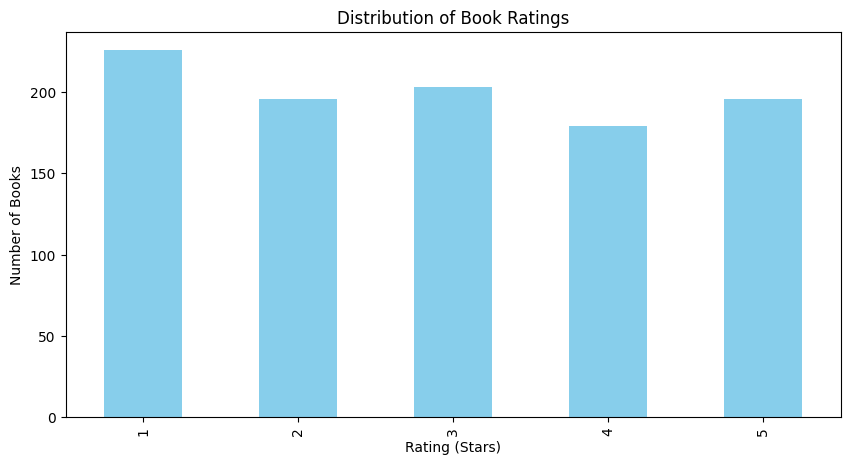

In [12]:
plt.figure(figsize=(10,5))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Books")
plt.show()

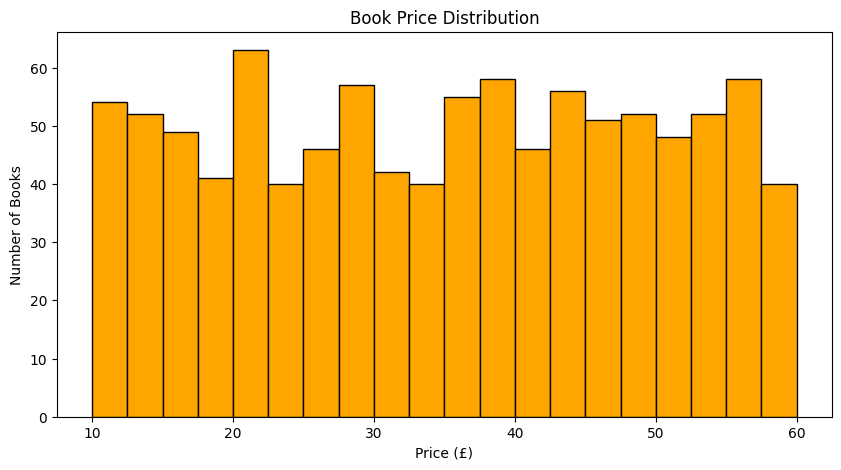

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df['Price'], bins=20, color='orange', edgecolor='black')
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

## SAVING CLEANED DATA

In [14]:
df.to_excel('books_Kenneth.xlsx', index=False)
print("✅ Cleaned data saved as 'books_Kenneth.xlsx'")

✅ Cleaned data saved as 'books_Kenneth.xlsx'


## PART B

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [16]:
base_url = "https://quotes.toscrape.com/page/{}/"
page = 1
quotes_data = []

In [17]:
while True:
    response = requests.get(base_url.format(page))
    soup = BeautifulSoup(response.text, 'html.parser')

    # Stop if no quotes found (end of pages)
    quotes = soup.find_all('div', class_='quote')
    if not quotes:
        break

    for quote in quotes:
        text = quote.find('span', class_='text').text.strip()
        author = quote.find('small', class_='author').text.strip()
        tags = [tag.text for tag in quote.find_all('a', class_='tag')]
        quotes_data.append({
            'Quote': text,
            'Author': author,
            'Tags': ', '.join(tags)
        })
    
    page += 1

In [18]:
soup

<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<title>Quotes to Scrape</title>
<link href="/static/bootstrap.min.css" rel="stylesheet"/>
<link href="/static/main.css" rel="stylesheet"/>
</head>
<body>
<div class="container">
<div class="row header-box">
<div class="col-md-8">
<h1>
<a href="/" style="text-decoration: none">Quotes to Scrape</a>
</h1>
</div>
<div class="col-md-4">
<p>
<a href="/login">Login</a>
</p>
</div>
</div>
<div class="row">
<div class="col-md-8">

No quotes found!

    <nav>
<ul class="pager">
<li class="previous">
<a href="/page/10/"><span aria-hidden="true">←</span> Previous</a>
</li>
</ul>
</nav>
</div>
<div class="col-md-4 tags-box">
<h2>Top Ten tags</h2>
<span class="tag-item">
<a class="tag" href="/tag/love/" style="font-size: 28px">love</a>
</span>
<span class="tag-item">
<a class="tag" href="/tag/inspirational/" style="font-size: 26px">inspirational</a>
</span>
<span class="tag-item">
<a class="tag" href="/tag/life/" style="font-size: 26px

In [19]:
df_quotes = pd.DataFrame(quotes_data)
df

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,3
1,Tipping the Velvet,53.74,In stock,1
2,Soumission,50.10,In stock,1
3,Sharp Objects,47.82,In stock,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,5
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,In stock,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,In stock,4
997,A Spy's Devotion (The Regency Spies of London #1),16.97,In stock,5
998,1st to Die (Women's Murder Club #1),53.98,In stock,1


In [20]:
df_quotes.to_csv('quotes_agume.csv', index=False)
print(" Quotes data saved as 'quotes_agume.csv'")
print(df_quotes.head())

 Quotes data saved as 'quotes_agume.csv'
                                               Quote           Author  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   
2  “There are only two ways to live your life. On...  Albert Einstein   
3  “The person, be it gentleman or lady, who has ...      Jane Austen   
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe   

                                           Tags  
0        change, deep-thoughts, thinking, world  
1                            abilities, choices  
2  inspirational, life, live, miracle, miracles  
3              aliteracy, books, classic, humor  
4                    be-yourself, inspirational  


- In this part, I scraped data from https://quotes.toscrape.com
, a website created specifically for web scraping practice. The goal was to collect all quotes, their respective authors, and tags across multiple pages using Python’s Requests and BeautifulSoup libraries. The extracted data was organized into a structured format and saved for further analysis.

Dataset Description
- Website Purpose: A public learning website for web scraping practice.
- Data Extracted: Quote text, Author, Tags.
- Challenges: Some pages required checking when to stop scraping once no quotes were found.
- Ethical Note: The site clearly allows scraping for educational purposes.
- Saved File: quotes_agume.csv